## 2D Resolution Estimation: FRC vs DCR

This notebook demonstrates 2D image resolution estimation using two complementary methods:

- **FRC** (Fourier Ring Correlation) — correlation-based, uses checkerboard splitting of a single image
- **DCR** (Decorrelation Analysis) — single-image, parameter-free

We compare results on three real super-resolution microscopy datasets from the original FRC and DCR papers.

**References:**
- Koho et al. (2019) "Fourier ring correlation simplifies image restoration in fluorescence microscopy", *Nature Communications* 10:3103.
- Descloux et al. (2019) "Parameter-free image resolution estimation based on decorrelation analysis", *Nature Methods* 16:918-924.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color

from cubic.metrics.frc.dcr import dcr_curve
from cubic.metrics.frc.frc import calculate_frc

In [ ]:
from pathlib import Path

import pooch

DATA_DIR = Path("../data")


def fetch_data(filename, url, known_hash):
    """Download file to DATA_DIR if not already present."""
    return pooch.retrieve(
        url=url,
        known_hash=f"sha256:{known_hash}",
        fname=filename,
        path=DATA_DIR,
    )


# Tubulin STED (Koho et al. 2019, figshare)
fetch_data(
    "Tubulin_057nm.tif",
    "https://ndownloader.figshare.com/files/15202592",
    "b14958909c605e61b1e77a6239c29b795a657d4fd175ae7edf438202fe83455a",
)

# Vimentin STED (Koho et al. 2019, figshare)
fetch_data(
    "Vimentin_029nm.tif",
    "https://ndownloader.figshare.com/files/15202565",
    "d22bed0e4c193884d25761a63ebf1ec17e4b8f5490da33409e568c0d3844a55a",
)

# COS7 STED (Descloux et al. 2019, ImDecorr GitHub — saved as test_image.tif upstream)
fetch_data(
    "demo_COS7_a-tub_abberior_star635_confocal_STED.tif",
    "https://github.com/Ades91/ImDecorr/raw/refs/heads/master/test_image.tif",
    "74d4ce76e67a5dd376655fff74231e026893198bd92458ab660c3fddb7c8288f",
)

In [2]:
def plot_frc_curve(frc_data, spacing, ax):
    """Plot FRC correlation curve with threshold and resolution crossing."""
    freq = np.asarray(frc_data.correlation["frequency"])
    corr = np.asarray(frc_data.correlation["correlation"])
    thr = np.asarray(frc_data.resolution["threshold"])
    res = frc_data.resolution["resolution"]

    ax.plot(freq, corr, "-", color="steelblue", linewidth=2, label="FRC")
    if "curve-fit" in frc_data.correlation.keys:
        curve_fit = np.asarray(frc_data.correlation["curve-fit"])
        ax.plot(
            freq, curve_fit, ":", color="steelblue", linewidth=1, alpha=0.7, label="fit"
        )
    ax.plot(freq, thr, "--", color="gray", linewidth=1, label="fixed (1/7)")

    if np.isfinite(res):
        cross_freq = frc_data.resolution["resolution-point"][1]
        ax.axvline(
            x=cross_freq,
            color="red",
            linestyle="--",
            alpha=0.7,
            label=f"f_c = {cross_freq:.3f}",
        )
        ax.set_title(f"FRC — {res * 1000:.1f} nm")
    else:
        ax.set_title("FRC — no crossing")

    ax.set_xlabel("Normalized frequency")
    ax.set_ylabel("FRC")
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.1, 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


def plot_dcr_curves(radii_refined, all_curves, all_peaks, ax, num_highpass=10):
    """Plot DCR decorrelation curves with correct x-axes.

    dcr_curve(refine=True) returns coarse curves (x in 0..1) followed by
    refined curves (x in the narrowed range given by ``radii_refined``).
    """
    n_coarse = num_highpass
    n_total = len(all_curves)
    has_refined = n_total > n_coarse
    num_points = len(all_curves[0])

    # Coarse curves span full 0..1 range
    radii_coarse = np.linspace(0, 1, num_points, dtype=np.float32)

    for i, d_curve in enumerate(all_curves):
        is_refined = has_refined and i >= n_coarse
        r = radii_refined if is_refined else radii_coarse
        alpha = 0.2 + 0.8 * (i / max(n_total - 1, 1))
        clr = "darkorange" if is_refined else "steelblue"
        ax.plot(r, d_curve, "-", color=clr, linewidth=1, alpha=alpha)

    # Find the overall peak (max r among all peaks)
    valid_peaks = all_peaks[all_peaks[:, 0] > 0]
    if len(valid_peaks) > 0:
        k_c_norm = float(np.max(valid_peaks[:, 0]))
        ax.axvline(
            x=k_c_norm,
            color="red",
            linestyle="--",
            alpha=0.7,
            label=f"k_c = {k_c_norm:.3f}",
        )

    ax.set_xlabel("Normalized frequency")
    ax.set_ylabel("Decorrelation")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


def measure_and_plot(image, spacing, title):
    """Compute FRC + DCR resolution and plot both curves."""
    frc_data = calculate_frc(image, spacing=spacing, curve_fit_type="smooth-spline")
    frc_res = frc_data.resolution["resolution"]

    dcr_res, dcr_radii, dcr_curves, dcr_peaks = dcr_curve(image, spacing=spacing)

    print(f"FRC resolution: {frc_res * 1000:.1f} nm")
    print(f"DCR resolution: {dcr_res * 1000:.1f} nm")

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    plot_frc_curve(frc_data, spacing, axes[0])
    plot_dcr_curves(dcr_radii, dcr_curves, dcr_peaks, axes[1])
    axes[1].set_title(f"DCR — {dcr_res * 1000:.1f} nm")
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return frc_res, dcr_res

### Dataset 1 — Tubulin STED (Koho et al. 2019, Figure 3)

Fixed cell with microtubule cytoskeleton stained with Star635, imaged on an
Abberior Instruments Expert Line STED system: 633 nm excitation, 100x/1.4
(UPLSAPO100XO) objective. Part of a pixel-size gradient series (29–113 nm);
this image uses 56.5 nm pixels.
Source: Koho et al. (2019) *Nat. Commun.* 10:3103,
[figshare dataset](https://doi.org/10.6084/m9.figshare.8158934.v1).

Raw shape: (708, 708, 3), dtype: uint8
Image shape: (708, 708)
Pixel size: 56.5 nm


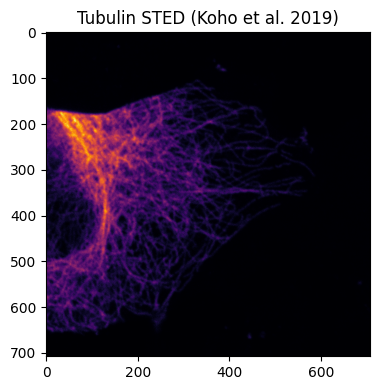

In [3]:
tubulin_rgb = io.imread("../data/Tubulin_057nm.tif")
print(f"Raw shape: {tubulin_rgb.shape}, dtype: {tubulin_rgb.dtype}")

# Convert RGB to grayscale float32
tubulin = color.rgb2gray(tubulin_rgb).astype(np.float32)
tubulin_spacing = 0.0565  # µm

print(f"Image shape: {tubulin.shape}")
print(f"Pixel size: {tubulin_spacing * 1000:.1f} nm")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(tubulin, cmap="inferno")
ax.set_title("Tubulin STED (Koho et al. 2019)")
plt.tight_layout()
plt.show()

FRC resolution: 287.8 nm
DCR resolution: 326.2 nm


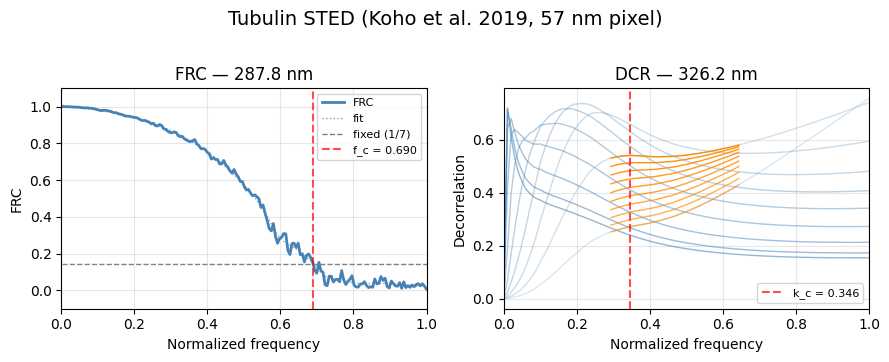

In [4]:
tubulin_frc_res, tubulin_dcr_res = measure_and_plot(
    tubulin,
    tubulin_spacing,
    "Tubulin STED (Koho et al. 2019, 57 nm pixel)",
)

### Dataset 2 — Vimentin STED (Koho et al. 2019)

Fixed cell with intermediate filaments (vimentin) cytoskeleton stained with
Star635, imaged on an Abberior Instruments Expert Line STED system: 633 nm
excitation, 100x/1.4 (UPLSAPO100XO) objective. Part of the same pixel-size
gradient series as Dataset 1 (29–113 nm); this image uses 29 nm pixels.
Source: Koho et al. (2019) *Nat. Commun.* 10:3103,
[figshare dataset](https://doi.org/10.6084/m9.figshare.8158934.v1).

Raw shape: (1389, 1389, 3), dtype: uint8
Image shape: (1389, 1389)
Pixel size: 29.0 nm


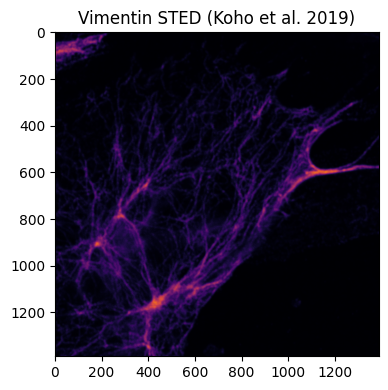

In [5]:
vimentin_rgb = io.imread("../data/Vimentin_029nm.tif")
print(f"Raw shape: {vimentin_rgb.shape}, dtype: {vimentin_rgb.dtype}")

# Convert RGB to grayscale float32
vimentin = color.rgb2gray(vimentin_rgb).astype(np.float32)
vimentin_spacing = 0.029  # µm

print(f"Image shape: {vimentin.shape}")
print(f"Pixel size: {vimentin_spacing * 1000:.1f} nm")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(vimentin, cmap="inferno")
ax.set_title("Vimentin STED (Koho et al. 2019)")
plt.tight_layout()
plt.show()

FRC resolution: 238.3 nm
DCR resolution: 286.8 nm


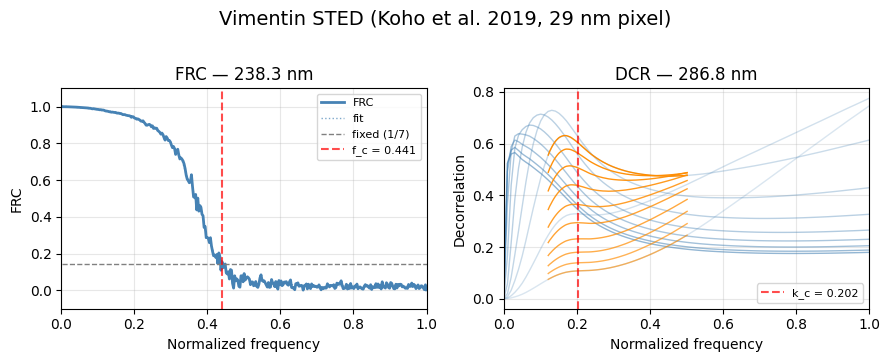

In [6]:
vimentin_frc_res, vimentin_dcr_res = measure_and_plot(
    vimentin,
    vimentin_spacing,
    "Vimentin STED (Koho et al. 2019, 29 nm pixel)",
)

### Dataset 3 — COS7 STED (Descloux et al. 2019, Figure 2c)

STED image of alpha-tubulin in COS7 cells labeled with Abberior STAR 635P.
Acquired on a Leica TCS SP8 STED 3X with HC PL APO CS2 100x/1.40 OIL objective:
634 nm excitation (11.2 µW), 775 nm STED depletion (201.5 mW), HyD detector
(645–720 nm, gain 100), pixel size 15 nm binned 2x, 8x frame average, 200 Hz,
time gate 1–11 ns, Mowiol-DABCO mounting.
Source: Descloux et al. (2019) *Nat. Methods* 16:918-924, Supplementary Table 1.

Raw shape: (510, 510), dtype: uint8
Image shape: (510, 510)
Pixel size: 15.3 nm


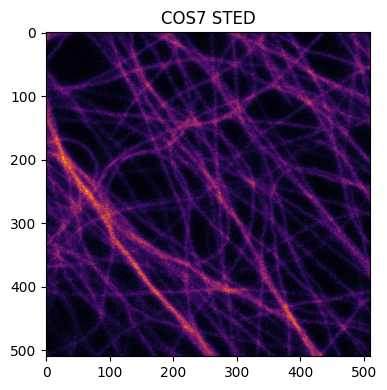

In [7]:
sted = io.imread("../data/demo_COS7_a-tub_abberior_star635_confocal_STED.tif")
print(f"Raw shape: {sted.shape}, dtype: {sted.dtype}")

sted = sted.astype(np.float32)
sted_spacing = 0.0153  # µm

print(f"Image shape: {sted.shape}")
print(f"Pixel size: {sted_spacing * 1000:.1f} nm")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sted, cmap="inferno")
ax.set_title("COS7 STED")
plt.tight_layout()
plt.show()

FRC resolution: 101.8 nm
DCR resolution: 111.0 nm


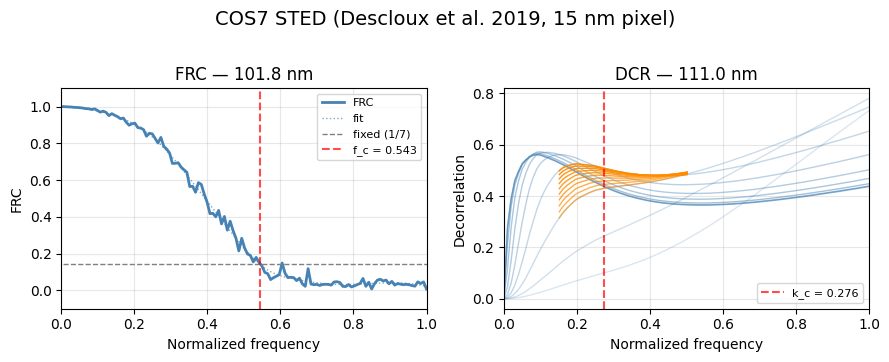

In [8]:
sted_frc_res, sted_dcr_res = measure_and_plot(
    sted,
    sted_spacing,
    "COS7 STED (Descloux et al. 2019, 15 nm pixel)",
)